# NeuroSleep — Notebook 02: Preprocessing & Feature Engineering

**Project**: Automated sleep stage classification from EEG signals using deep learning.

**Author**: Marcos Vinícius Rocha Gomes

**Date**: May 2026

---

## Objectives of this notebook

1. Build a reproducible preprocessing pipeline for raw EEG signals.
2. Load multiple subjects from Sleep-EDF and segment them into labeled 30-second epochs.
3. Engineer features in three domains: **time**, **frequency**, and **wavelet**.
4. Build a complete feature matrix `X` and label vector `y` ready for modeling.
5. Validate the discriminative power of features through visualization and basic statistics.
6. Persist processed data to disk (Parquet) for fast reloading in modeling notebooks.

## Pipeline overview

```
Raw EDF files
    ↓
Bandpass filter (0.3 - 35 Hz)  →  removes drift + high-frequency noise
    ↓
Epoching (30-s windows)        →  AASM standard
    ↓
Robust normalization           →  median / IQR per recording
    ↓
Feature extraction:
    • Time domain (Hjorth, RMS, ZC, skewness, kurtosis)
    • Frequency domain (relative band power: δ, θ, α, β, γ)
    • Wavelet domain (energy per decomposition level)
    ↓
Feature matrix → Parquet on disk
```

## 1. Imports and configuration

In [7]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mne
from mne.datasets.sleep_physionet.age import fetch_data

import pywt
from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis

mne.set_log_level("WARNING")
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

# Paths
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Configuration constants

We centralize hyperparameters so they're easy to tune later.

In [8]:
# Subjects to process. Start with 5 for fast iteration; increase later.
SUBJECTS = list(range(5))
RECORDING_NIGHT = 1

# Filtering
BANDPASS_LOW = 0.3   # Hz — remove DC drift
BANDPASS_HIGH = 35.0 # Hz — sleep EEG content lies below this

# Epoching (AASM standard)
EPOCH_DURATION = 30.0  # seconds

# Channels of interest for sleep staging
EEG_CHANNELS = ["EEG Fpz-Cz", "EEG Pz-Oz"]

# Stage mapping (R&K -> 5-class standard, with N3+N4 merged)
EVENT_ID = {
    "Sleep stage W": 1,
    "Sleep stage 1": 2,
    "Sleep stage 2": 3,
    "Sleep stage 3": 4,
    "Sleep stage 4": 4,
    "Sleep stage R": 5,
}
CODE_TO_STAGE = {1: "W", 2: "N1", 3: "N2", 4: "N3", 5: "REM"}
STAGE_ORDER = ["W", "N1", "N2", "N3", "REM"]

# Frequency bands (Hz) — neurophysiology standard
FREQ_BANDS = {
    "delta": (0.5, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta":  (13.0, 30.0),
    "gamma": (30.0, 35.0),
}

# Wavelet decomposition
WAVELET = "db4"      # Daubechies 4 — classic choice for EEG
WAVELET_LEVEL = 5

print(f"Will process {len(SUBJECTS)} subjects: {SUBJECTS}")

Will process 5 subjects: [0, 1, 2, 3, 4]


## 3. Preprocessing pipeline

### Why bandpass 0.3 - 35 Hz?
- **Low cutoff (0.3 Hz)**: removes slow baseline drift caused by perspiration, electrode polarization, etc.
- **High cutoff (35 Hz)**: removes power line noise (50/60 Hz) and muscle artifacts (>40 Hz). Almost all sleep-relevant EEG content is below 35 Hz.

### Why robust normalization (median / IQR)?
Raw EEG amplitudes vary across subjects due to electrode impedance, scalp conductivity, etc. Standard z-score (mean/std) is sensitive to outliers (artifacts). Median/IQR is more robust.

In [9]:
def preprocess_recording(psg_file: str, hypnogram_file: str) -> mne.Epochs:
    """Load, filter, epoch, and normalize a single PSG recording."""
    # Load
    raw = mne.io.read_raw_edf(psg_file, preload=True, stim_channel="Event marker")
    raw.pick(EEG_CHANNELS)

    # Bandpass filter (zero-phase FIR)
    raw.filter(BANDPASS_LOW, BANDPASS_HIGH, fir_design="firwin")

    # Attach hypnogram annotations
    annotations = mne.read_annotations(hypnogram_file)
    raw.set_annotations(annotations, emit_warning=False)

    # Crop to the period containing sleep (drop long Wake tails)
    # We keep 30 minutes around the first and last non-Wake event
    mask = annotations.description != "Sleep stage W"
    if mask.any():
        tmin = max(annotations.onset[mask].min() - 30 * 60, 0)
        tmax = min(annotations.onset[mask].max() + 30 * 60, raw.times[-1])
        raw.crop(tmin=tmin, tmax=tmax)

    # Build 30-second epochs from annotations
    events, event_id_used = mne.events_from_annotations(
        raw, event_id=EVENT_ID, chunk_duration=EPOCH_DURATION
    )
    tmax_epoch = EPOCH_DURATION - 1.0 / raw.info["sfreq"]
    epochs = mne.Epochs(
        raw=raw,
        events=events,
        event_id=event_id_used,
        tmin=0.0,
        tmax=tmax_epoch,
        baseline=None,
        preload=True,
    )

    # Robust normalization per channel: (x - median) / IQR
    data = epochs.get_data()  # shape: (n_epochs, n_channels, n_samples)
    n_ch = data.shape[1]
    for ch in range(n_ch):
        flat = data[:, ch, :].reshape(-1)
        med = np.median(flat)
        iqr = np.percentile(flat, 75) - np.percentile(flat, 25)
        if iqr > 0:
            data[:, ch, :] = (data[:, ch, :] - med) / iqr

    # Reinject normalized data
    epochs._data = data
    return epochs


# Quick test on subject 0
files = fetch_data(subjects=[0], recording=[RECORDING_NIGHT])
psg_file, hypno_file = files[0]
epochs_test = preprocess_recording(psg_file, hypno_file)
print(f"Preprocessed shape: {epochs_test.get_data().shape}")
print("  -> (n_epochs, n_channels, n_samples_per_epoch)")

Preprocessed shape: (1689, 2, 3000)
  -> (n_epochs, n_channels, n_samples_per_epoch)


## 4. Feature engineering

We implement three categories of features. Each function operates on a single 1D signal (one channel, one epoch) and returns a dictionary of named features. We concatenate everything at the end.

### 4.1 Time-domain features

- **Mean, std, skewness, kurtosis**: basic statistical descriptors.
- **Hjorth parameters** (activity, mobility, complexity): classical EEG descriptors capturing signal variance, mean frequency, and frequency change.
- **RMS** (root-mean-square): overall energy.
- **Zero-crossings rate**: a cheap proxy for dominant frequency.

In [10]:
def hjorth_parameters(x: np.ndarray) -> tuple[float, float, float]:
    """Compute Hjorth activity, mobility, and complexity."""
    dx = np.diff(x)
    ddx = np.diff(dx)
    var_x = np.var(x)
    var_dx = np.var(dx)
    var_ddx = np.var(ddx)

    activity = var_x
    mobility = np.sqrt(var_dx / var_x) if var_x > 0 else 0.0
    complexity = (np.sqrt(var_ddx / var_dx) / mobility) if (var_dx > 0 and mobility > 0) else 0.0
    return activity, mobility, complexity


def time_domain_features(x: np.ndarray) -> dict:
    activity, mobility, complexity = hjorth_parameters(x)
    zero_crossings = np.sum(np.diff(np.sign(x)) != 0) / len(x)
    return {
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "skew": float(skew(x)),
        "kurtosis": float(kurtosis(x)),
        "rms": float(np.sqrt(np.mean(x ** 2))),
        "zcr": float(zero_crossings),
        "hjorth_activity": float(activity),
        "hjorth_mobility": float(mobility),
        "hjorth_complexity": float(complexity),
    }


# Smoke test
sample_epoch = epochs_test.get_data()[0, 0, :]
print("Time-domain features (sample epoch, channel 0):")
for k, v in time_domain_features(sample_epoch).items():
    print(f"  {k:25s} {v:+.4f}")

Time-domain features (sample epoch, channel 0):
  mean                      -0.0103
  std                       +0.8460
  skew                      -0.7253
  kurtosis                  +1.8369
  rms                       +0.8460
  zcr                       +0.1263
  hjorth_activity           +0.7157
  hjorth_mobility           +0.3018
  hjorth_complexity         +4.4502


### 4.2 Frequency-domain features

We compute the **Power Spectral Density (PSD)** using Welch's method, then integrate the power within each physiological band (δ, θ, α, β, γ). Reporting **relative power** (each band divided by total) makes features comparable across subjects.

In [11]:
def frequency_domain_features(x: np.ndarray, sfreq: float) -> dict:
    # Welch PSD
    nperseg = min(len(x), int(4 * sfreq))  # 4-second segments
    freqs, psd = scipy_signal.welch(x, fs=sfreq, nperseg=nperseg)

    total_power = float(np.trapezoid(psd, freqs))
    features = {"total_power": total_power}

    for band_name, (low, high) in FREQ_BANDS.items():
        mask = (freqs >= low) & (freqs <= high)
        band_power = float(np.trapezoid(psd[mask], freqs[mask]))
        features[f"{band_name}_power"] = band_power
        features[f"{band_name}_relative"] = band_power / total_power if total_power > 0 else 0.0

    # Spectral entropy: how "flat" the spectrum is
    psd_norm = psd / psd.sum() if psd.sum() > 0 else psd
    psd_norm = psd_norm[psd_norm > 0]
    features["spectral_entropy"] = float(-np.sum(psd_norm * np.log2(psd_norm)))

    # Spectral edge frequency (95% of cumulative power)
    cumulative = np.cumsum(psd)
    if cumulative[-1] > 0:
        sef = freqs[np.searchsorted(cumulative, 0.95 * cumulative[-1])]
    else:
        sef = 0.0
    features["spectral_edge_95"] = float(sef)

    return features


sfreq = epochs_test.info["sfreq"]
print("Frequency-domain features (sample epoch, channel 0):")
for k, v in frequency_domain_features(sample_epoch, sfreq).items():
    print(f"  {k:25s} {v:+.4f}")

Frequency-domain features (sample epoch, channel 0):
  total_power               +0.7365
  delta_power               +0.5808
  delta_relative            +0.7886
  theta_power               +0.0546
  theta_relative            +0.0742
  alpha_power               +0.0094
  alpha_relative            +0.0128
  beta_power                +0.0172
  beta_relative             +0.0234
  gamma_power               +0.0040
  gamma_relative            +0.0054
  spectral_entropy          +4.3448
  spectral_edge_95          +7.0000


### 4.3 Wavelet-domain features

Wavelets give time-frequency localization: better than FFT at capturing transient events (sleep spindles, K-complexes). We compute the discrete wavelet transform (DWT) with Daubechies-4 and extract energy per decomposition level.

In [12]:
def wavelet_domain_features(x: np.ndarray, wavelet: str = WAVELET, level: int = WAVELET_LEVEL) -> dict:
    coeffs = pywt.wavedec(x, wavelet=wavelet, level=level)
    features = {}
    total_energy = sum(np.sum(c ** 2) for c in coeffs)
    for i, c in enumerate(coeffs):
        # coeffs[0] is approximation (lowest freqs), rest are details
        label = "a" if i == 0 else f"d{level - i + 1}"
        energy = float(np.sum(c ** 2))
        features[f"wav_{label}_energy"] = energy
        features[f"wav_{label}_relative"] = energy / total_energy if total_energy > 0 else 0.0
        features[f"wav_{label}_std"] = float(np.std(c))
    return features


print("Wavelet features (sample epoch, channel 0):")
for k, v in wavelet_domain_features(sample_epoch).items():
    print(f"  {k:30s} {v:+.4f}")

Wavelet features (sample epoch, channel 0):
  wav_a_energy                   +1185.7116
  wav_a_relative                 +0.5429
  wav_a_std                      +3.4427
  wav_d5_energy                  +568.5719
  wav_d5_relative                +0.2604
  wav_d5_std                     +2.3839
  wav_d4_energy                  +278.8643
  wav_d4_relative                +0.1277
  wav_d4_std                     +1.1989
  wav_d3_energy                  +73.4651
  wav_d3_relative                +0.0336
  wav_d3_std                     +0.4387
  wav_d2_energy                  +43.1857
  wav_d2_relative                +0.0198
  wav_d2_std                     +0.2392
  wav_d1_energy                  +34.0522
  wav_d1_relative                +0.0156
  wav_d1_std                     +0.1505


### 4.4 Feature aggregator

Combines all three categories for one epoch (one channel) into a single flat dict.

In [13]:
def extract_features(x: np.ndarray, sfreq: float, channel_name: str) -> dict:
    """Extract all features for a single 1D signal. Prefixes them with channel name."""
    features = {}
    for k, v in time_domain_features(x).items():
        features[f"{channel_name}__time__{k}"] = v
    for k, v in frequency_domain_features(x, sfreq).items():
        features[f"{channel_name}__freq__{k}"] = v
    for k, v in wavelet_domain_features(x).items():
        features[f"{channel_name}__wavelet__{k}"] = v
    return features

## 5. Build the full feature matrix

We iterate over all configured subjects, preprocess each one, extract features for every epoch and every channel, and concatenate everything into one big DataFrame.

In [14]:
def process_subject(subject_id: int, recording: int = RECORDING_NIGHT) -> pd.DataFrame | None:
    """Process one subject's recording end-to-end. Returns a feature DataFrame or None on failure."""
    try:
        files = fetch_data(subjects=[subject_id], recording=[recording])
        psg_file, hypno_file = files[0]
        epochs = preprocess_recording(psg_file, hypno_file)

        data = epochs.get_data()  # (n_epochs, n_channels, n_samples)
        sfreq = epochs.info["sfreq"]
        labels = [CODE_TO_STAGE[c] for c in epochs.events[:, 2]]

        rows = []
        for ep_idx in range(data.shape[0]):
            row = {"subject": subject_id, "epoch_idx": ep_idx, "stage": labels[ep_idx]}
            for ch_idx, ch_name in enumerate(epochs.ch_names):
                clean_ch = ch_name.replace(" ", "_").replace("-", "_")
                row.update(extract_features(data[ep_idx, ch_idx, :], sfreq, clean_ch))
            rows.append(row)

        return pd.DataFrame(rows)
    except Exception as e:
        print(f"  [!] Failed to process subject {subject_id}: {e}")
        return None


all_dfs = []
for sid in SUBJECTS:
    print(f"Processing subject {sid}...")
    df = process_subject(sid)
    if df is not None:
        print(f"  -> {len(df)} epochs, {df.shape[1] - 3} features")
        all_dfs.append(df)

features_df = pd.concat(all_dfs, ignore_index=True)
print(f"\nFull feature matrix: {features_df.shape}")
features_df.head()

Processing subject 0...


  -> 1689 epochs, 80 features
Processing subject 1...


  -> 2144 epochs, 80 features
Processing subject 2...


  -> 2135 epochs, 80 features
Processing subject 3...


  -> 2009 epochs, 80 features
Processing subject 4...
  [!] Failed to process subject 4: ('Connection broken: IncompleteRead(30047940 bytes read, 16830908 more expected)', IncompleteRead(30047940 bytes read, 16830908 more expected))

Full feature matrix: (7977, 83)


,subject,epoch_idx,stage,EEG_Fpz_Cz__time__mean,EEG_Fpz_Cz__time__std,EEG_Fpz_Cz__time__skew,EEG_Fpz_Cz__time__kurtosis,EEG_Fpz_Cz__time__rms,EEG_Fpz_Cz__time__zcr,EEG_Fpz_Cz__time__hjorth_activity,...,EEG_Pz_Oz__wavelet__wav_d4_std,EEG_Pz_Oz__wavelet__wav_d3_energy,EEG_Pz_Oz__wavelet__wav_d3_relative,EEG_Pz_Oz__wavelet__wav_d3_std,EEG_Pz_Oz__wavelet__wav_d2_energy,EEG_Pz_Oz__wavelet__wav_d2_relative,EEG_Pz_Oz__wavelet__wav_d2_std,EEG_Pz_Oz__wavelet__wav_d1_energy,EEG_Pz_Oz__wavelet__wav_d1_relative,EEG_Pz_Oz__wavelet__wav_d1_std
0,0,0,W,-0.010293,0.845975,-0.725261,1.836892,0.846037,0.126333,0.715673,...,0.588373,195.922717,0.300480,0.717099,55.674790,0.085387,0.271542,12.234122,0.018763,0.090221
1,0,1,W,0.012239,1.043280,-0.285562,1.190647,1.043352,0.110333,1.088433,...,0.596593,162.880144,0.160465,0.653840,67.325809,0.066327,0.298376,27.567534,0.027159,0.135431
2,0,2,W,-0.016720,1.301271,-0.176219,0.302116,1.301379,0.062000,1.693307,...,0.642846,88.733412,0.084911,0.481985,49.985559,0.047832,0.257249,19.878583,0.019022,0.115004
3,0,3,W,-0.027321,1.073884,-0.243075,0.653293,1.074232,0.101333,1.153228,...,0.640865,76.428281,0.071050,0.447767,55.901205,0.051967,0.272105,32.539694,0.030250,0.147139
4,0,4,W,0.006450,1.158477,-0.193799,0.255570,1.158495,0.088667,1.342068,...,0.599387,138.946358,0.092272,0.603884,60.837278,0.040401,0.283686,22.755043,0.015111,0.123044


## 6. Sanity checks

Before saving and modeling, verify there are no NaNs, infinities, or empty stages.

In [15]:
n_nan = features_df.isna().sum().sum()
n_inf = np.isinf(features_df.select_dtypes(include=[np.number]).values).sum()
print(f"NaN cells: {n_nan}")
print(f"Inf cells: {n_inf}")
print("\nClass distribution across all subjects:")
print(features_df["stage"].value_counts().reindex(STAGE_ORDER, fill_value=0))

NaN cells: 0
Inf cells: 0

Class distribution across all subjects:
stage
W      4669
N1      322
N2     1842
N3      477
REM     667
Name: count, dtype: int64


In [16]:
# Replace any infs with NaN, then drop rows with NaNs (extreme edge case)
features_df = features_df.replace([np.inf, -np.inf], np.nan)
before = len(features_df)
features_df = features_df.dropna()
after = len(features_df)
print(f"Dropped {before - after} rows due to NaN/Inf. Remaining: {after}")

Dropped 0 rows due to NaN/Inf. Remaining: 7977


## 7. Feature validation through visualization

Two quick checks:

1. **Delta band power should be highest in N3** (slow-wave sleep).
2. **Beta band power should be highest in Wake**.

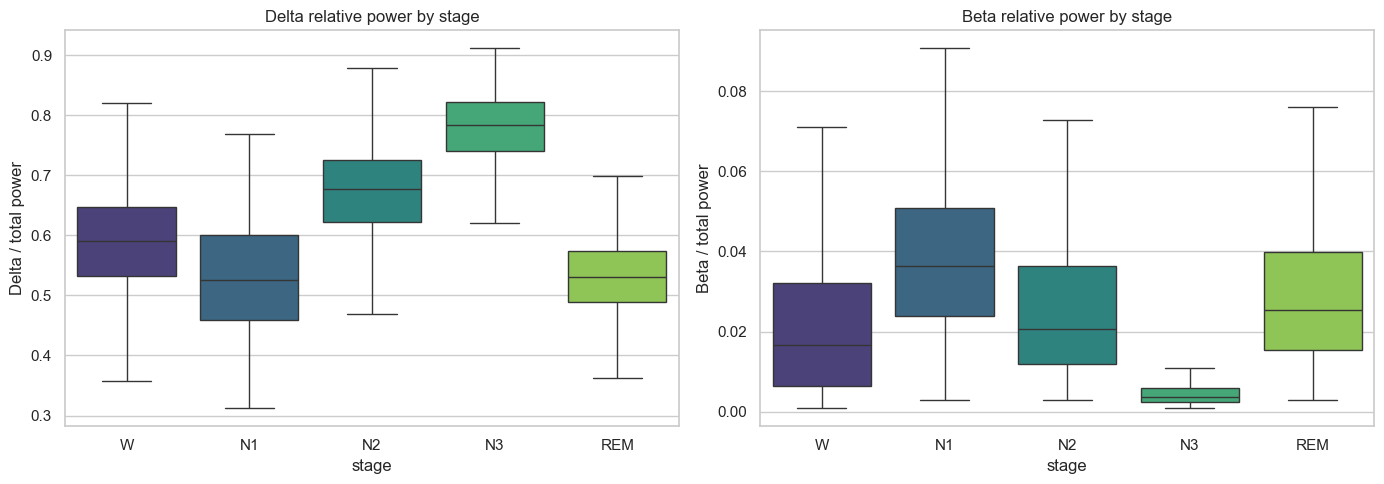

In [17]:
ch = EEG_CHANNELS[0].replace(" ", "_").replace("-", "_")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=features_df,
    x="stage", y=f"{ch}__freq__delta_relative",
    order=STAGE_ORDER, palette="viridis", showfliers=False, ax=axes[0],
)
axes[0].set_title("Delta relative power by stage")
axes[0].set_ylabel("Delta / total power")

sns.boxplot(
    data=features_df,
    x="stage", y=f"{ch}__freq__beta_relative",
    order=STAGE_ORDER, palette="viridis", showfliers=False, ax=axes[1],
)
axes[1].set_title("Beta relative power by stage")
axes[1].set_ylabel("Beta / total power")

plt.tight_layout()
plt.show()

If the plots show:
- **Delta** clearly elevated in **N3** vs other stages
- **Beta** clearly elevated in **W** vs deeper stages

...then our features carry real discriminative signal. This is the sanity check before throwing them at a model.

## 8. Feature-feature relationships

Correlation heatmap of a subset of features, colored by stage means. Helps spot redundant features (which we may want to prune later).

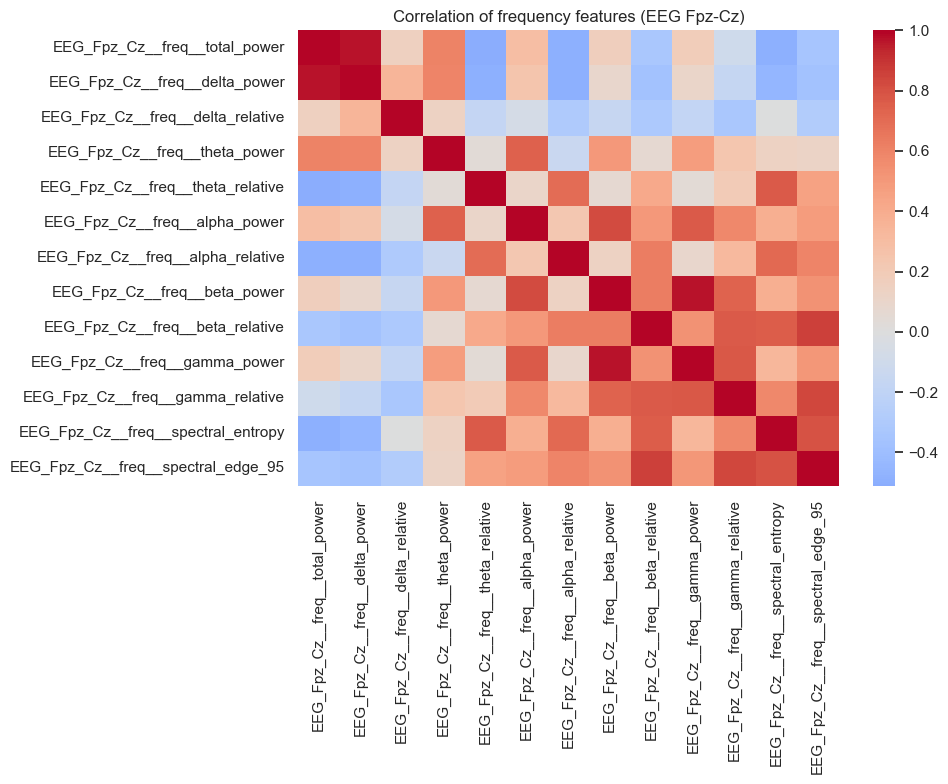

In [18]:
feature_cols = [c for c in features_df.columns if c.startswith(ch + "__freq__")]
corr = features_df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title(f"Correlation of frequency features ({EEG_CHANNELS[0]})")
plt.tight_layout()
plt.show()

## 9. Save processed data

We persist the feature matrix to Parquet for fast reloading in the modeling notebooks. Parquet is columnar, compressed, and preserves dtypes — much better than CSV for ML pipelines.

In [20]:
features_path = PROCESSED_DIR / "features.parquet"
features_df.to_parquet(features_path, index=False)

file_size_mb = features_path.stat().st_size / 1024 / 1024
print(f"Saved features to {features_path}")
print(f"File size: {file_size_mb:.2f} MB")
print(f"Shape: {features_df.shape}")
print(f"\nFeature columns sample:")
for col in features_df.columns[3:13]:
    print(f"  - {col}")

ArrowKeyError: No type extension with name arrow.py_extension_type found

## 10. Also save raw epochs for the deep learning notebook

The CNN in Notebook 04 needs the raw (normalized) signal, not engineered features. We save those separately as a NumPy archive.

In [ ]:
all_signals = []
all_labels = []
all_subjects = []

for sid in SUBJECTS:
    try:
        files = fetch_data(subjects=[sid], recording=[RECORDING_NIGHT])
        psg_file, hypno_file = files[0]
        epochs = preprocess_recording(psg_file, hypno_file)
        data = epochs.get_data().astype(np.float32)  # save memory
        labels = np.array([CODE_TO_STAGE[c] for c in epochs.events[:, 2]])

        all_signals.append(data)
        all_labels.append(labels)
        all_subjects.append(np.full(len(labels), sid))
    except Exception as e:
        print(f"Skipping subject {sid}: {e}")

X = np.concatenate(all_signals, axis=0)
y = np.concatenate(all_labels, axis=0)
subjects_arr = np.concatenate(all_subjects, axis=0)

signals_path = PROCESSED_DIR / "epochs.npz"
np.savez_compressed(signals_path, X=X, y=y, subjects=subjects_arr)

print(f"Saved signal data to {signals_path}")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  File size: {signals_path.stat().st_size / 1024 / 1024:.2f} MB")

## 11. Summary and next steps

### What we built

- A reproducible preprocessing pipeline (filter → epoch → robust normalization).
- Three families of features:
  - **Time domain** (9 features per channel): means, dispersion, Hjorth, ZCR.
  - **Frequency domain** (~13 features per channel): band powers, relative powers, spectral entropy, edge frequency.
  - **Wavelet domain** (~18 features per channel): energy and std per decomposition level.
- A feature matrix saved as Parquet, ready for classical ML.
- Raw normalized epochs saved as `.npz`, ready for deep learning.

### Quick validation

Delta band power elevated in N3 and beta elevated in Wake — features carry signal.

### Next steps

- **Notebook 03**: Baseline classifiers (Random Forest, SVM) on engineered features. Establish metrics and confusion matrices we will need to beat.
- **Notebook 04**: CNN 1D in TensorFlow/Keras on the raw signal. Compare against baseline.
- **Persistence**: log experiments to MLflow and store metrics in PostgreSQL.